# Healthcare Analytics for Improving Patient Outcomes

# Overview
 
This project focuses on analysing hospital operations and patient data to uncover trends, evaluate resource utilisation, and provide actionable insights for improving service quality and patient outcomes. By leveraging data analytics techniques, the goal is to optimise hospital processes, improve patient care, enhance operational efficiency, and identify areas for resource optimisation. The analysis will include descriptive statistics, trend analysis, and visualisation to aid decision-making. 

# Problem Statement
 
The objective of this project is to analyse hospital and patient data to identify trends and patterns that influence key outcomes, including patient length of stay, billing amounts, resource allocation, and service quality. 

#### The project will focus on the following areas: 
● Assessing how patient demographics and medical conditions correlate with resource 
utilisation. 
● Analysing billing patterns and identifying cost-saving opportunities. 
● Evaluating hospital operations by looking at variables like admission type, discharge 
dates, and room utilisation. 
● Providing insights for hospital management to improve operational efficiency and 
patient care. 

## Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
sns.set(style = 'whitegrid')
# plt.rcParams['figure.figsize'] = (10,6)

In [2]:
healthcare = pd.read_csv('healthcare_dataset.csv')
healthcare.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,09-10-2022,Penicillin,Abnormal


## 1. Exploratory Data Analysis (EDA)

### Basic Information

In [4]:
healthcare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [5]:
healthcare.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224655,202.000000
50%,52.000000,25538.069380,302.000000
75%,68.000000,37820.508432,401.000000
max,89.000000,52764.276740,500.000000


In [32]:
healthcare.describe(include = 'all')

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
count,55500,55500.000000,55500,55500,55500,55500,55500,55500,55500,55500.000000,55500.000000,55500,55500,55500,55500
unique,49992,NaN,2,8,6,NaN,40341,39876,5,NaN,NaN,3,NaN,5,3
top,DAvId muNoZ,NaN,Male,A-,Arthritis,NaN,Michael Smith,LLC Smith,Cigna,NaN,NaN,Elective,NaN,Lipitor,Abnormal
freq,3,NaN,27774,6969,9308,NaN,27,44,11249,NaN,NaN,18655,NaN,11140,18627
mean,NaN,51.539459,NaN,NaN,NaN,2021-11-01 01:02:22.443243008,NaN,NaN,NaN,25539.316097,301.134829,NaN,2021-11-16 13:15:20.821621504,NaN,NaN
min,NaN,13.000000,NaN,NaN,NaN,2019-05-08 00:00:00,NaN,NaN,NaN,-2008.492140,101.000000,NaN,2019-05-09 00:00:00,NaN,NaN
25%,NaN,35.000000,NaN,NaN,NaN,2020-07-28 00:00:00,NaN,NaN,NaN,13241.224655,202.000000,NaN,2020-08-12 00:00:00,NaN,NaN
50%,NaN,52.000000,NaN,NaN,NaN,2021-11-01 00:00:00,NaN,NaN,NaN,25538.069380,302.000000,NaN,2021-11-17 00:00:00,NaN,NaN
75%,NaN,68.000000,NaN,NaN,NaN,2023-02-03 00:00:00,NaN,NaN,NaN,37820.508432,401.000000,NaN,2023-02-18 00:00:00,NaN,NaN
max,NaN,89.000000,NaN,NaN,NaN,2024-05-07 00:00:00,NaN,NaN,NaN,52764.276740,500.000000,NaN,2024-06-06 00:00:00,NaN,NaN


In [6]:
healthcare.dtypes

Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

In [7]:
healthcare.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

### Distribution Analysis

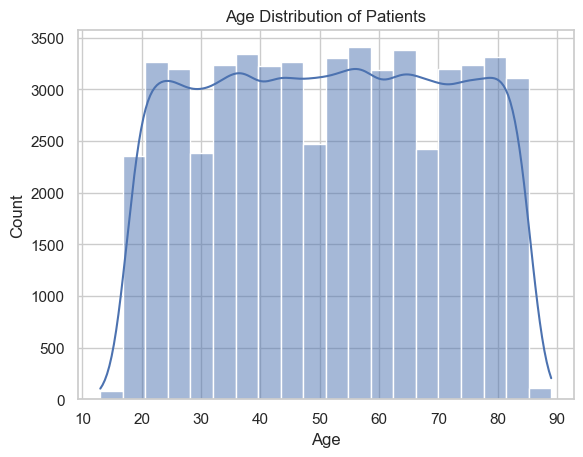

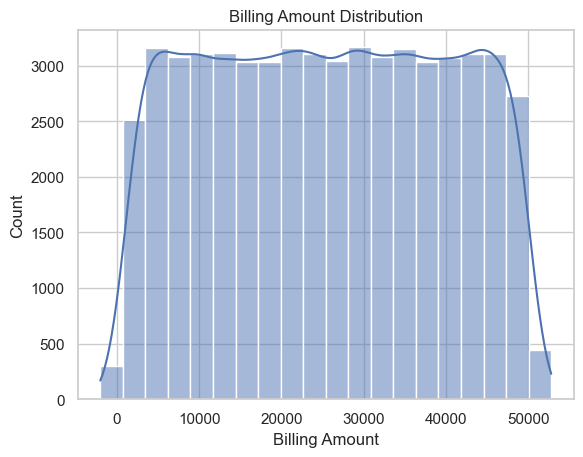

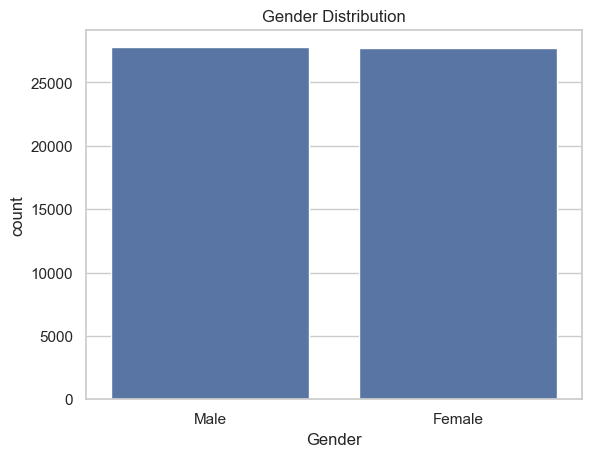

In [3]:
# Age distribution

sns.histplot(healthcare['Age'], bins = 20, kde = True)
plt.title('Age Distribution of Patients')
plt.show ()

# Billing Amount distribution

sns.histplot(healthcare['Billing Amount'], bins = 20, kde = True)
plt.title('Billing Amount Distribution')
plt.show()

# Gender count
sns.countplot(x = 'Gender', data = healthcare)
plt.title('Gender Distribution')
plt.show()


### Relationships between Variables

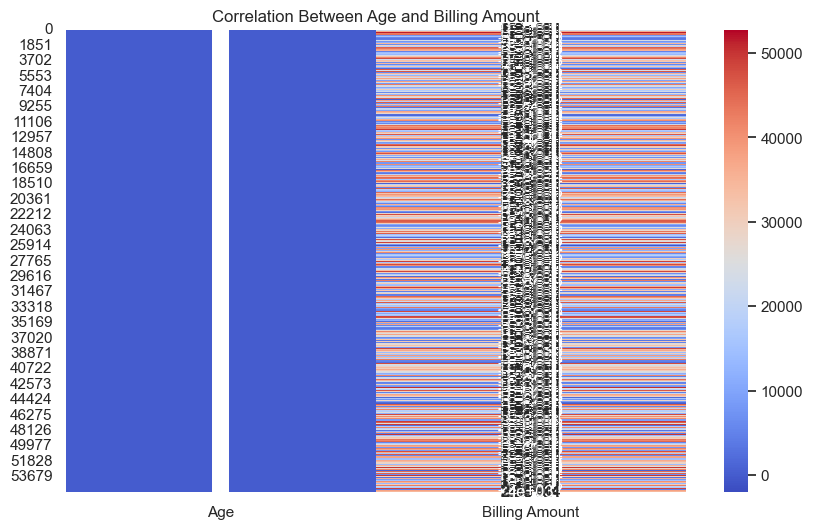

In [7]:
# Correlation between numerical columns

corr = healthcare[['Age', 'Billing Amount']]
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Correlation Between Age and Billing Amount')
plt.show()

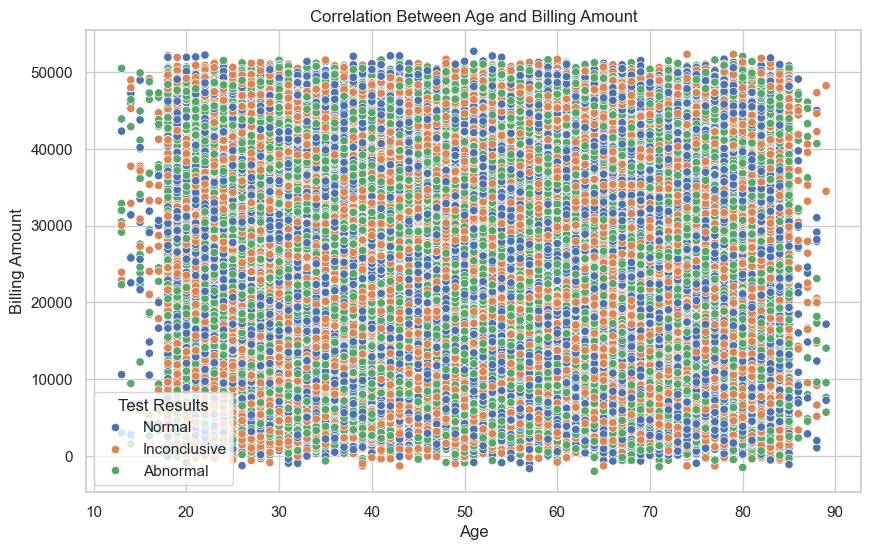

In [8]:
# Correlation between numerical columns

sns.scatterplot(x ='Age', y = 'Billing Amount',hue = 'Test Results', data = healthcare)
plt.title('Correlation Between Age and Billing Amount')
plt.show()

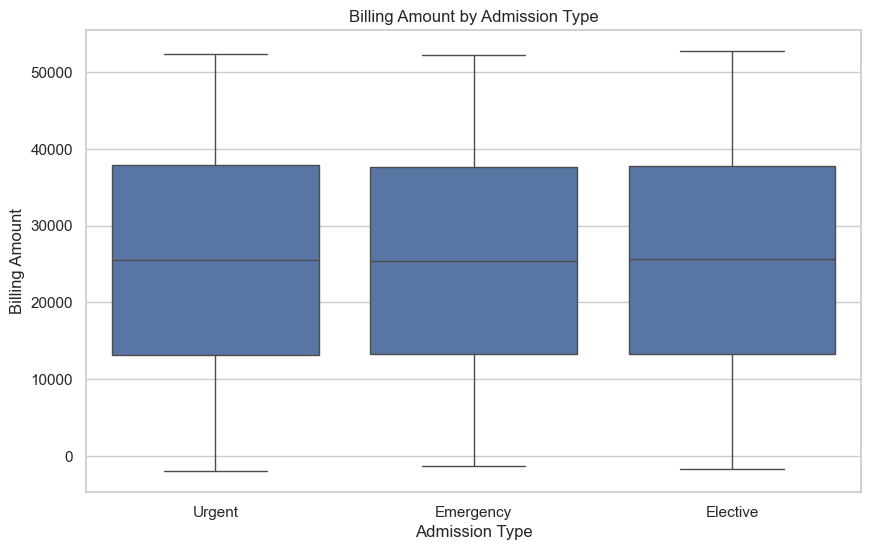

In [9]:
# Admission Type vs Billing Amount
sns.boxplot(
    x = 'Admission Type',
    y = 'Billing Amount',
    data = healthcare
)
plt.title('Billing Amount by Admission Type')
plt.show()

## 2. Data Preprocessing

### Change Data Type

In [11]:
healthcare.dtypes

Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

In [4]:
# Convert from object to datetime
healthcare['Date of Admission'] = pd.to_datetime(healthcare['Date of Admission'],dayfirst = True)
healthcare['Discharge Date'] = pd.to_datetime(healthcare['Discharge Date'], dayfirst = True)

In [12]:
healthcare.dtypes

Name                          object
Age                            int64
Gender                        object
Blood Type                    object
Medical Condition             object
Date of Admission     datetime64[ns]
Doctor                        object
Hospital                      object
Insurance Provider            object
Billing Amount               float64
Room Number                    int64
Admission Type                object
Discharge Date        datetime64[ns]
Medication                    object
Test Results                  object
dtype: object

### Handle Missing Values

In [5]:
# Fill missing numerical values with median
healthcare['Billing Amount'].fillna(healthcare['Billing Amount'].median(), inplace = True)

# Fill missing categorical values with mode
categorical_col = ['Gender', 'Blood Type', 'Medical Condition', 'Doctor', 'Hospital', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']
for category in categorical_col:
    healthcare[category].fillna(healthcare[category].mode()[0], inplace = True)

# Handle missing dates
# Convert from object to datetime
healthcare['Date of Admission'] = pd.to_datetime(healthcare['Date of Admission'])
healthcare['Discharge Date'] = pd.to_datetime(healthcare['Discharge Date'], dayfirst = True)

C:\Users\shwet\AppData\Local\Temp\ipykernel_23204\3927754611.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  healthcare['Billing Amount'].fillna(healthcare['Billing Amount'].median(), inplace = True)
C:\Users\shwet\AppData\Local\Temp\ipykernel_23204\3927754611.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting

In [36]:
healthcare.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,2022-10-09,Penicillin,Abnormal


### Feature Engineering

In [6]:
# Length of stay in days
healthcare['Length of Stay'] = (healthcare['Discharge Date'] - healthcare['Date of Admission']).dt.days

# Room utilization flag
healthcare['Room Occupied'] = healthcare['Room Number'].notnull().astype(int)

### Categorical Encoding

In [7]:
# Convert categorical variables to category dtype for analysis/ml

for category in categorical_col:
    healthcare[category] = healthcare[category].astype('category')

In [16]:
healthcare.dtypes

Name                          object
Age                            int64
Gender                      category
Blood Type                  category
Medical Condition           category
Date of Admission     datetime64[ns]
Doctor                      category
Hospital                    category
Insurance Provider          category
Billing Amount               float64
Room Number                    int64
Admission Type              category
Discharge Date        datetime64[ns]
Medication                  category
Test Results                category
Length of Stay                 int64
Room Occupied                  int64
dtype: object

## 3. Trend Analysis

### Patient Length of Stay

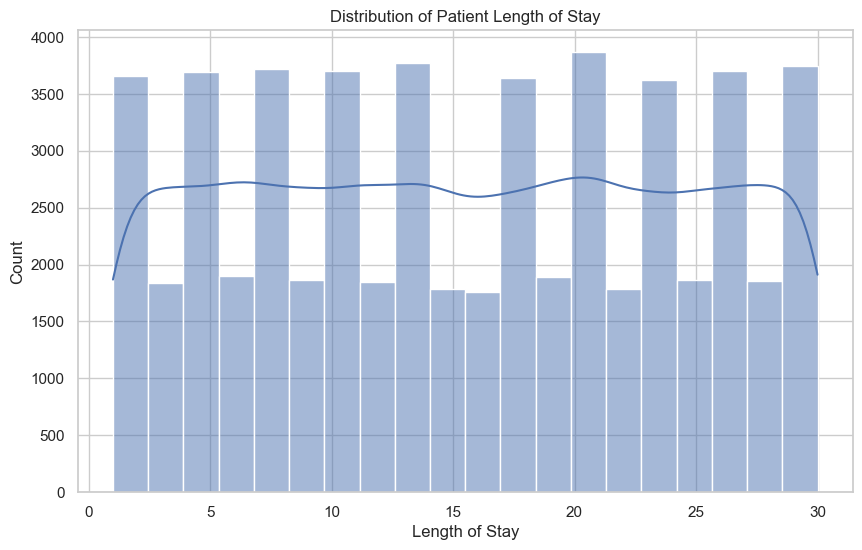

In [17]:
sns.histplot(healthcare['Length of Stay'], bins = 20, kde = True)
plt.title('Distribution of Patient Length of Stay')
plt.show()

In [18]:
# average length of stay
print('Average Length of Stay:', healthcare['Length of Stay'].mean())

Average Length of Stay: 15.50900900900901


### Billing Amount Trends

In [ ]:
# Average billing per hospital

avg_billing_hospital = healthcare.groupby('Hospital')['Billing Amount'].mean().sort_values(ascending=False)
avg_billing_hospital.plot(kind = 'bar', color = 'skyblue')
plt.title('Averge Billing Amount per Hospital')
plt.ylabel('Average Billing Amount')
plt.tight_layout()
plt.show()

In [ ]:
# Average billing per hospital

avg_billing_hospital = healthcare.groupby('Hospital')['Billing Amount'].mean().sort_values(ascending=False)
avg_billing_hospital.plot(kind = 'barh', color = 'skyblue', edgecolor = 'black')
plt.title('Averge Billing Amount per Hospital')
plt.xlabel('Average Billing Amount')
plt.ylabel('Hospital')
plt.tight_layout()
plt.show()

C:\Users\shwet\AppData\Local\Temp\ipykernel_23204\4252165317.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  healthcare.groupby('Hospital')['Billing Amount'].mean().sort_values(ascending = False).head(10)


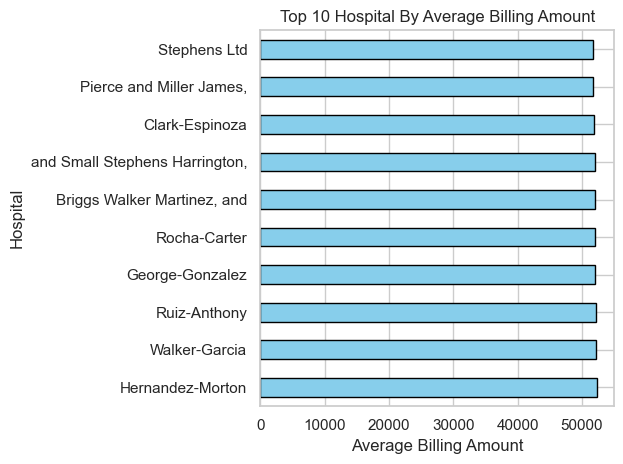

In [8]:
# Average billing of top 10 hospital
top10 = (
    healthcare.groupby('Hospital')['Billing Amount'].mean().sort_values(ascending = False).head(10)
)
top10.plot(kind = 'barh', color = 'skyblue', edgecolor = 'black')
plt.title('Top 10 Hospital By Average Billing Amount')
plt.xlabel('Average Billing Amount')
plt.ylabel('Hospital')
plt.tight_layout()
plt.show()

In [3]:
healthcare.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,09-10-2022,Penicillin,Abnormal


### Admission Type Analysis

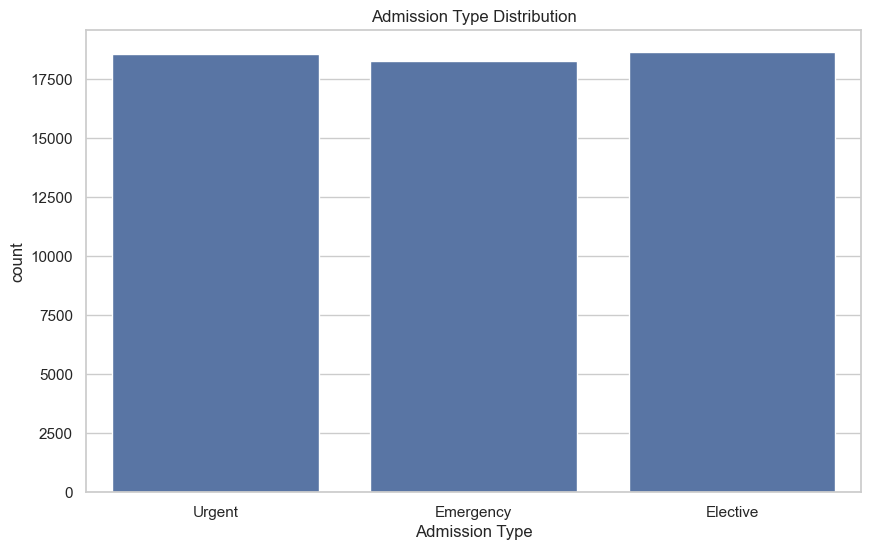

In [4]:
# Admission type distribution
sns.countplot(x = 'Admission Type', data = healthcare)
plt.title('Admission Type Distribution')
plt.show()

### Room Utilisation

In [14]:
# Room utilisation rate
room_utilization_rate = healthcare['Room Occupied'].mean()
print('Room Utilization Rate:', round(room_utilization_rate * 100, 2), '%')

Room Utilization Rate: 100.0 %


## 4. Key Metrics Analysis

In [16]:
# Average patient billing amounts
avg_billing = healthcare['Billing Amount'].mean()
print('Average Patient Billing Amount:', round(avg_billing, 2))

# Length of stay analysis
length_of_stay_stats = healthcare['Length of Stay'].describe()
print(length_of_stay_stats)

# Admission type distribution
admission_counts = healthcare['Admission Type'].value_counts()
print(admission_counts)

Average Patient Billing Amount: 25539.32
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64
Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64


## 5. Recommendations Based on Analysis

1. Optimize Room Utilisation: If room utilisation is below optimal (<70%), implement scheduling strategies to reduce empty room days.

2. Manage Length of Stay: Identify conditions with longer-than-average stays and review care protocols to reduce unnecessary hospital days.

3. Control Billing Costs: Analyze high-billing patients and treatment plans to identify cost-saving opportunities without compromising care.

4. Admission Type Management: Track urgent vs. non-urgent admissions to improve resource allocation and emergency preparedness.

5. Data Standardization: Maintain consistent data entry for patient demographics, medications, and test results to enable faster reporting and predictive analytics.

## 6. Report

### 1. Executive Summary

This report presents an in-depth analysis of hospital patient data to uncover operational trends, cost drivers, and resource utilization patterns. Using exploratory data analysis (EDA), data preprocessing, and trend analysis techniques, key insights were derived to support decision-making aimed at improving hospital efficiency, cost control, and patient care quality.

The analysis focuses on:

Patient demographics
Length of hospital stay
Admission types
Billing patterns
Room utilization

### 2. Key Findings & Insights
#### Patient Demographics

Patient age distribution shows a wide range, with most patients falling in the adult and senior categories.

Gender distribution is relatively balanced, suggesting no demographic bias in admissions.

Visuals Used: Age histogram, Gender bar chart

#### Length of Stay Analysis

The average length of stay indicates most patients are discharged within a reasonable timeframe.

However, outliers exist, where certain patients remain hospitalized significantly longer.

Longer stays are often linked to specific medical conditions or urgent admissions.

 Visuals Used: Length of stay histogram, Box plot

Business Insight:
Extended hospital stays increase operational costs and reduce room availability.

#### Billing Amount Trends

Billing amounts vary widely across patients.

Urgent admissions generally result in higher billing amounts than non-urgent cases.

Certain hospitals exhibit consistently higher average billing, indicating potential differences in service pricing or case severity.

Visuals Used: Billing histogram, Billing by admission type box plot, Hospital-wise bar chart

Business Insight:
Billing variability highlights opportunities for cost optimization and pricing standardization.

#### Admission Type Distribution

The majority of admissions fall into non-urgent categories.

Urgent admissions, while fewer, consume disproportionately higher resources.

Visuals Used: Admission type bar chart

Business Insight:
Better triaging of non-urgent cases could reduce strain on hospital resources.

#### Room Utilization

Room utilization rate indicates that not all rooms are optimally used.

Periods of underutilization suggest inefficiencies in admission planning and discharge coordination.

Visuals Used: Room utilization metrics and summaries

Business Insight:
Improving room turnover can significantly increase hospital capacity without infrastructure expansion.

### 3. Key Performance Metrics
Metric	Observation
Average Billing Amount	Indicates overall treatment cost per patient
Average Length of Stay	Key driver of operational efficiency
Room Utilization Rate	Measures infrastructure efficiency
Urgent vs Non-Urgent Ratio	Reflects emergency resource demand

These metrics directly support capacity planning, staffing, and financial forecasting.

### 4. Conclusion

This analysis demonstrates how healthcare data can be leveraged to:

Improve operational efficiency

Reduce unnecessary costs

Enhance patient care quality

Support strategic planning

By acting on the insights and recommendations provided, hospitals can achieve better resource utilization, financial sustainability, and improved patient outcomes.

### 5. Next Steps

Predictive modeling for length of stay

Cost forecasting by admission type

Patient outcome and readmission analysis

Real-time operational dashboards